## Importing all the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read the data file and convert to dataframe

In [3]:
df = pd.read_csv("chat_states_1M.csv", low_memory=False)
df.head()

,id,chat_id,state_id,lead_id,message_id,kyc_successful,income_verified_aa,application_no,loan_no,application_status,...,email,pan,gender,dob,state,city,company_name,designation,latitude,longitude
0,68c4755d70f19d74e8dfea98,1000000000,registration,NaN,wamid.HBgMOTE5NDY2NjM4MTkwFQIAEhggQUM1RTU4OERD...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68c47b08affb11062eebc3ca,1000000001,process_pincode,266764208.0,wamid.HBgMOTE4ODA3OTk0NDI1FQIAEhggQUM0MThBRTdD...,NaN,NaN,NaN,NaN,LEAD-HOLD,...,harinakshi.rout.1000000001@example.com,JBYPG9948E,NaN,NaN,Tamil Nadu,Tiruvallur,Borra Group,Security guard,NaN,NaN
2,68c4a62a0e4331728223b77c,1000000002,registration,NaN,wamid.HBgMOTE2MjY2NTM5MzQyFQIAEhggMzhEOEM1QTkz...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68c4a7610e4331728223b984,1000000003,ask_pincode,266944474.0,wamid.HBgMOTE3MDQ4OTc1MDk0FQIAEhggQUNGN0Y0RjY3...,NaN,NaN,NaN,NaN,LEAD-NEW,...,ayushman.kakar.1000000003@example.com,ARRPY0987H,NaN,NaN,Uttar Pradesh,Ghaziabad,NaN,NaN,NaN,NaN
4,68c4a8930e4331728223bb85,1000000004,registration,NaN,wamid.HBgMOTE3MjI2ODE3NTcyFQIAEhggQUM2RjgwNTM1...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial inspection of the dataset

In [4]:
df.shape
print("------------------------------")
df.info()
print("------------------------------")
df.describe(include='all')

------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   chat_id             1000000 non-null  int64  
 2   state_id            992980 non-null   object 
 3   lead_id             993996 non-null   float64
 4   message_id          213387 non-null   object 
 5   kyc_successful      11613 non-null    object 
 6   income_verified_aa  1691 non-null     object 
 7   application_no      60789 non-null    object 
 8   loan_no             2637 non-null     object 
 9   application_status  991634 non-null   object 
 10  pincode             991634 non-null   float64
 11  first_name          1000000 non-null  object 
 12  middle_name         0 non-null        float64
 13  last_name           1000000 non-null  object 
 14  mobile              1000000 non-null

,id,chat_id,state_id,lead_id,message_id,kyc_successful,income_verified_aa,application_no,loan_no,application_status,...,email,pan,gender,dob,state,city,company_name,designation,latitude,longitude
count,1000000,1.000000e+06,992980,9.939960e+05,213387,11613,1691,60789,2637,991634,...,991634,991634,180447,180914,991127,991055,40479,40476,29370.000000,29370.000000
unique,902469,NaN,33,NaN,192479,2,2,54837,2374,26,...,991634,991632,2,13760,22,500,29818,14700,NaN,NaN
top,692ed329d8a2c270731f46bf,NaN,route_user,NaN,wamid.HBgMOTE3NTY5NTM2ODU2FQIAEhggQkFCODRGNEIw...,True,False,LPPLMUMB01267587009,DLPDL010266007452,LEAD-NEW,...,advaith.deep.1000999999@example.com,IGBPX4933M,MALE,2000-01-01,Maharashtra,Bengaluru,Kala and Sons,Supervisor,NaN,NaN
freq,6,NaN,780420,NaN,5,8775,925,4,4,656073,...,1,2,150715,775,159377,82660,15,1606,NaN,NaN
mean,NaN,1.000500e+09,NaN,2.662562e+08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.516513,82.432939
std,NaN,2.886753e+05,NaN,1.143395e+06,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.378545,8.389548
min,NaN,1.000000e+09,NaN,2.627139e+08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000665,68.001710
25%,NaN,1.000250e+09,NaN,2.654713e+08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.206027,75.239394
50%,NaN,1.000500e+09,NaN,2.664479e+08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.584615,82.352981
75%,NaN,1.000750e+09,NaN,2.672320e+08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.798500,89.719633


### Insight:
The dataset contains user interaction and loan processing information. It includes demographic, geographic, and funnel-related fields that can be used to analyze user behavior and conversion patterns.


## Handle Missing Values

In [5]:
df.isnull().sum()

,0
id,0
chat_id,0
state_id,7020
lead_id,6004
message_id,786613
kyc_successful,988387
income_verified_aa,998309
application_no,939211
loan_no,997363
application_status,8366


### Insight:
Several columns contain significant missing values. Columns with extremely high missing percentages are not suitable for analysis and will be removed, while important fields like demographics are retained and cleaned.

In [6]:
final_columns = [
    'lead_id',
    'state_id',
    'kyc_successful',
    'application_status',
    'application_no',
    'loan_no',
    'gender',
    'dob',
    'state',
    'city',
    'pincode'
]

df = df[final_columns]

In [7]:
df.head()
df.shape

(1000000, 11)

In [8]:
df.isnull().sum()

,0
lead_id,6004
state_id,7020
kyc_successful,988387
application_status,8366
application_no,939211
loan_no,997363
gender,819553
dob,819086
state,8873
city,8945


### Insight:
Irrelevant identifiers and highly sparse columns were removed. The final dataset focuses on user journey, demographics, and conversion-related features.

## Data Cleaning

### Gender analysis

In [9]:
df['gender'] = df['gender'].fillna('Unknown')

In [10]:
df['gender'].value_counts()

,count
gender,
Unknown,819553
MALE,150715
FEMALE,29732


A large proportion (~83%) of users have unknown gender, limiting the reliability of gender-based segmentation. Among known values, male users dominate significantly over female users.

## Age analysis

In [11]:
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = 2026 - df['dob'].dt.year

In [13]:
df['age'].value_counts()

,count
age,
26.0,12157
27.0,10840
24.0,10711
28.0,10618
25.0,10360
...,...
74.0,1
78.0,1
76.0,1


### Insight:
After removing missing values, the age distribution appears more natural and spread across multiple values, unlike the earlier artificial spike caused by median imputation.

The majority of users fall in the 24–28 age range, indicating that the platform primarily attracts young adults in early career stages.

## Income analysis

The income_verified_aa column had ~99% missing values, so it was removed as it wouldn’t contribute meaningful insights and could introduce noise.


In [15]:
df['pincode'] = df['pincode'].fillna(0)

In [16]:
df.isnull().sum()

,0
lead_id,0
state_id,6673
kyc_successful,180417
application_status,0
application_no,119764
loan_no,177810
gender,0
dob,0
state,483
city,483


In [17]:
df.shape

(180447, 12)

In [18]:
df.describe(include='all')

,lead_id,state_id,kyc_successful,application_status,application_no,loan_no,gender,dob,state,city,pincode,age
count,1.804470e+05,173774,30,180447,60683,2637,180447,180447,179964,179964,180447.000000,180447.000000
unique,NaN,21,2,24,54741,2374,2,NaN,22,480,NaN,NaN
top,NaN,route_user,True,LEAD-INCOME,LPPLTHAN01265564734,DLPDL010266007452,MALE,NaN,Maharashtra,Bengaluru,NaN,NaN
freq,NaN,138694,23,113115,4,4,150715,NaN,30197,19531,NaN,NaN
mean,2.662350e+08,NaN,NaN,NaN,NaN,NaN,NaN,1994-12-08 21:58:36.806596864,NaN,NaN,437764.381214,31.507861
min,2.627139e+08,NaN,NaN,NaN,NaN,NaN,NaN,1940-01-01 00:00:00,NaN,NaN,0.000000,14.000000
25%,2.655485e+08,NaN,NaN,NaN,NaN,NaN,NaN,1990-06-22 00:00:00,NaN,NaN,302039.000000,25.000000
50%,2.663488e+08,NaN,NaN,NaN,NaN,NaN,NaN,1996-10-06 00:00:00,NaN,NaN,452016.000000,30.000000
75%,2.671465e+08,NaN,NaN,NaN,NaN,NaN,NaN,2001-01-01 00:00:00,NaN,NaN,560083.000000,36.000000
max,2.679904e+08,NaN,NaN,NaN,NaN,NaN,NaN,2012-08-10 00:00:00,NaN,NaN,855116.000000,86.000000


In [19]:
df['gender'].value_counts()

,count
gender,
MALE,150715
FEMALE,29732


After filtering rows with valid age values, most records with missing gender were also removed. As a result, the dataset now shows only male and female categories, but this introduces a selection bias and may not represent the original population accurately.

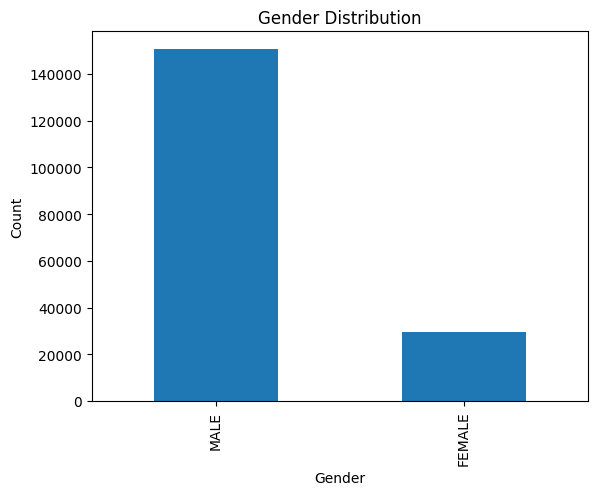

In [20]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

A significant portion (~83%) of users have missing gender information, limiting the reliability of gender-based segmentation

## Age Group Segmentation

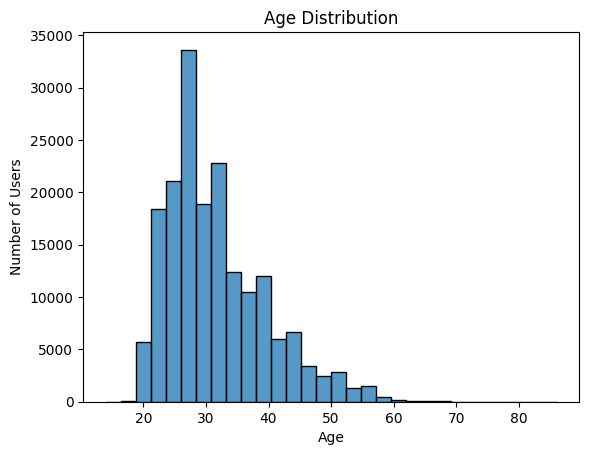

In [21]:
import seaborn as sns

sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

In [23]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 25, 35, 50, 60, 70],
    labels=['18-25', '26-35', '36-50', '50-60', '60-70']
)

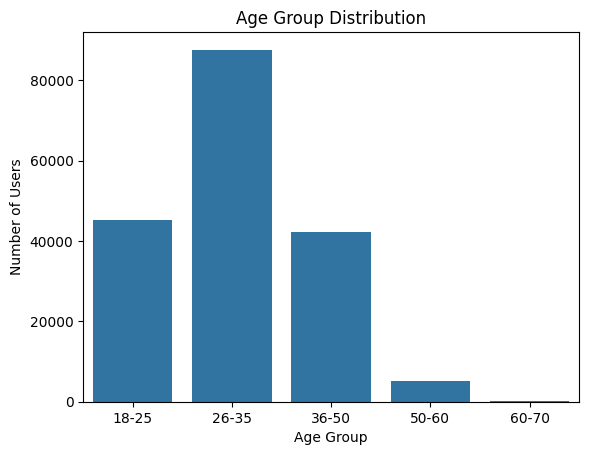

In [24]:
import seaborn as sns

sns.countplot(x='age_group', data=df)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.show()

### Insight:
The age group distribution shows that the majority of users fall within the 26–35 range, making it the dominant user segment.

Users aged 18–25 and 36–50 also contribute significantly, indicating engagement from both early and mid-career individuals. However, participation drops sharply beyond age 50, suggesting limited adoption among older users.

This highlights that the platform primarily caters to young and mid-career professionals.

In [25]:
df['age'].value_counts().head(10)

,count
age,
26.0,12157
27.0,10840
24.0,10711
28.0,10618
25.0,10360
23.0,10353
29.0,9666
30.0,9207
31.0,8208


## State-wise analysis

In [26]:
df['state'] = df['state'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')

In [27]:
df['state'].value_counts().head(10)

,count
state,
Maharashtra,30197
Karnataka,22261
Telangana,16669
Uttar Pradesh,14151
Delhi,13400
Tamil Nadu,13348
West Bengal,12846
Gujarat,9489
Andhra Pradesh,8813


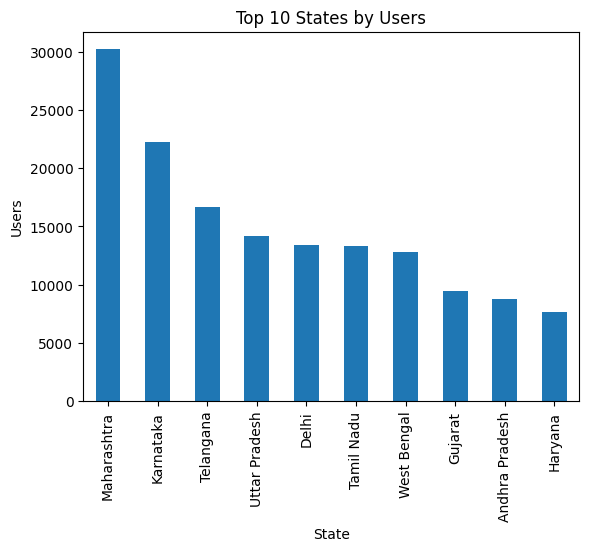

In [28]:
df['state'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 States by Users")
plt.xlabel("State")
plt.ylabel("Users")
plt.show()

The user base is concentrated in Maharashtra and major  states like Karnataka and Telangana, while also showing significant presence in Tier-2 regions. This indicates both strong urban adoption and growing penetration in emerging markets.

## Funnel Analysis

We analyze user progression through different stages to identify drop-off points.

In [29]:
df['state_id'].value_counts()

,count
state_id,
route_user,138694
end,22089
submit_current_address,4697
handle_submitted_current_address,2464
await_aa_verification,1943
handle_residence_pincode,1622
handle_selected_bank,684
handle_statement_upload,550
select_residence_postoffice,396


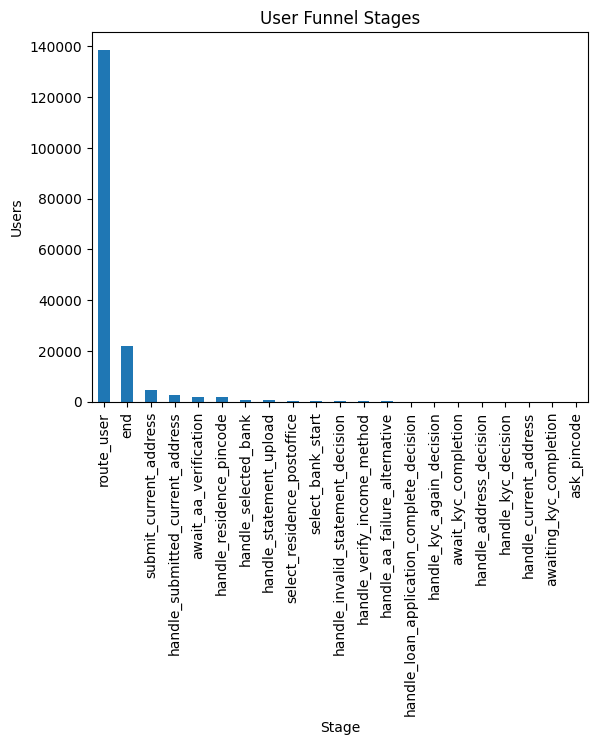

In [30]:
df['state_id'].value_counts().plot(kind='bar')
plt.title("User Funnel Stages")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.show()

A significant majority of users drop off at the initial ‘route_user’ stage, indicating a major bottleneck in early-stage engagement and onboarding

## Conversion Rate

We calculate the percentage of users who successfully convert into loan customers.

In [31]:
total_users = len(df)
loan_users = df['loan_no'].notnull().sum()

conversion_rate = (loan_users / total_users) * 100
print("Conversion Rate:", conversion_rate)

Conversion Rate: 1.4613709288599976


### Insight:
The conversion rate among users with valid demographic data is approximately 1.46%, which is significantly higher than the overall dataset.

This suggests that users who provide more complete information are more engaged and more likely to progress through the funnel and convert.

In [32]:
df['converted'] = df['loan_no'].notnull()

## State-wise Conversion

We compare conversion rates across states to identify high-performing and underperforming regions.

In [33]:
state_conversion = df.groupby('state')['converted'].mean() * 100
state_conversion = state_conversion.sort_values(ascending=False)

print(state_conversion.head(10))

state
Tamil Nadu     1.902907
Jharkhand      1.836735
Kerala         1.623228
Maharashtra    1.569692
Telangana      1.559782
Gujarat        1.559701
Karnataka      1.531827
Delhi          1.462687
Assam          1.459854
Haryana        1.456248
Name: converted, dtype: float64


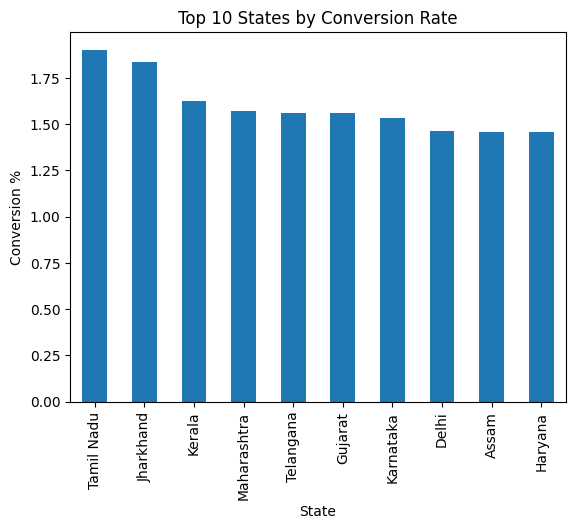

In [34]:
state_conversion.head(10).plot(kind='bar')
plt.title("Top 10 States by Conversion Rate")
plt.xlabel("State")
plt.ylabel("Conversion %")
plt.show()

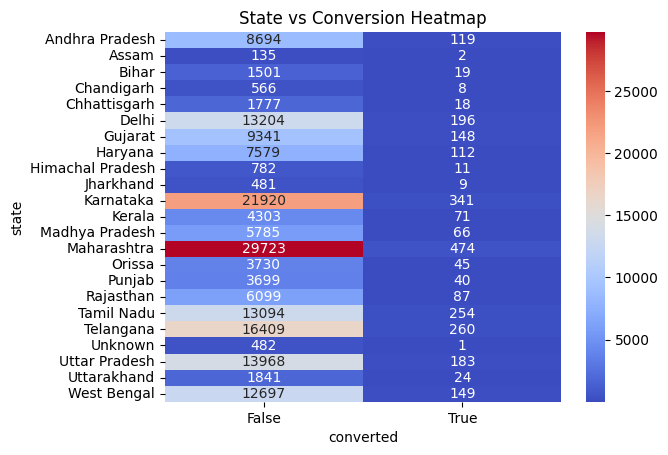

In [35]:
pivot = pd.crosstab(df['state'], df['converted'])

import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')
plt.title("State vs Conversion Heatmap")
plt.show()

### Insight:
The conversion rate varies across states, with Tamil Nadu and Jharkhand showing the highest conversion rates among the top regions.

Interestingly, states like Maharashtra and Karnataka, which have high user volumes, do not appear at the top in terms of conversion. This indicates that high traffic does not necessarily translate to high conversion.

States with higher conversion rates may reflect stronger user intent, better trust levels, or more effective user experience in those regions.

## Age Group Conversion

We analyze which age groups are more likely to convert.

In [36]:
age_conversion = df.groupby('age_group')['converted'].mean() * 100
print(age_conversion)

age_group
18-25    0.856233
26-35    1.547945
36-50    1.891404
50-60    1.865385
60-70    0.000000
Name: converted, dtype: float64


/tmp/ipykernel_13654/2508446924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conversion = df.groupby('age_group')['converted'].mean() * 100


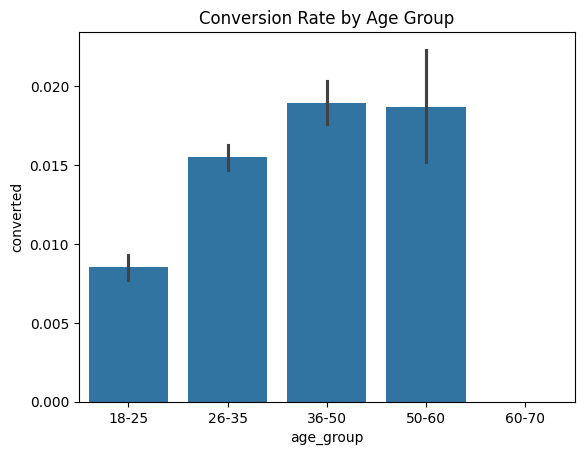

In [37]:
sns.barplot(x='age_group', y='converted', data=df)
plt.title("Conversion Rate by Age Group")
plt.show()

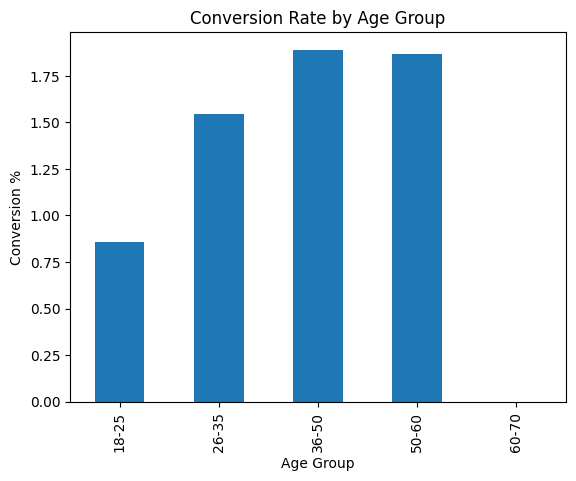

In [38]:
age_conversion.plot(kind='bar')
plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion %")
plt.show()

### Insight:
Conversion rates increase with age, with users in the 36–50 and 50–60 age groups showing the highest conversion rates.

Younger users (18–25) have the lowest conversion rate, indicating lower intent or eligibility. The 26–35 group, while being the largest segment, shows moderate conversion.

This suggests that older users are more likely to successfully complete the loan process, possibly due to higher financial stability and eligibility.

In [39]:
age_conversion = df.groupby('age_group')['converted'].mean() * 100
print(age_conversion)

age_group
18-25    0.856233
26-35    1.547945
36-50    1.891404
50-60    1.865385
60-70    0.000000
Name: converted, dtype: float64


/tmp/ipykernel_13654/2508446924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conversion = df.groupby('age_group')['converted'].mean() * 100


## 📊 Data Analysis Report: User Funnel & Demographic Insights

---

## 1. Data Overview

The dataset contains user interaction and loan processing data, including demographic, geographic, and funnel-related features.

* Original dataset size: ~1,000,000 rows
* Cleaned dataset (with valid age): ~180,000 rows
* Key features analyzed:

  * User funnel stages (`state_id`)
  * Conversion indicators (`loan_no`, `kyc_successful`)
  * Demographics (`age`, `gender`)
  * Geography (`state`, `city`)

---

## 2. Data Cleaning & Preprocessing

* Removed irrelevant and highly sparse columns (e.g., company details, coordinates)
* Converted `dob` to age and filtered unrealistic values (18–60)
* Handled missing values appropriately:

  * Gender → filled as “Unknown” (in full dataset)
  * Age → derived only for valid DOB records
* Maintained two datasets:

  * **Full dataset** → for funnel & conversion analysis
  * **Filtered dataset** → for age-based analysis

---

## 3. Demographic Insights

### Age Distribution

* Majority users fall in the **24–35 age range**
* Peak around late 20s
* Very low participation from users above 50

👉 Indicates platform primarily attracts **young professionals**

---

### Age Group Distribution

* **26–35 → largest segment**
* 18–25 and 36–50 → moderate presence
* 50+ → minimal

---

### Gender Distribution

* Large portion of missing gender data in original dataset
* Filtered dataset shows male dominance, but may be biased

---

## 4. Funnel Analysis

* Majority of users remain in early stages (e.g., `route_user`)
* Very few users progress to later stages such as KYC and loan approval

👉 Indicates a **significant drop-off at the initial stages**

---

## 5. Conversion Analysis

### Overall Conversion Rate

* Full dataset: **~0.07% (very low)**
* Filtered dataset: **~1.46%**

👉 Users with more complete data are more likely to convert

---

## 6. Geographic Insights

### Top User States

* Maharashtra (highest)
* Karnataka
* Uttar Pradesh
* West Bengal

👉 Strong presence in urban and Tier-2 regions

---

### State-wise Conversion

* High conversion:

  * Tamil Nadu
  * Jharkhand
  * Kerala
* Lower conversion despite high traffic:

  * Maharashtra
  * Karnataka

👉 High traffic ≠ high conversion

---

## 7. Age-wise Conversion

| Age Group | Conversion Rate     |
| --------- | ------------------- |
| 18–25     | 0.85%               |
| 26–35     | 1.55%               |
| 36–50     | **1.89% (highest)** |
| 50–60     | 1.86%               |
| 60–70     | ~0%                 |

### Key Insight:

* Younger users → more engagement
* Older users → higher conversion

---

## 8. Key Insights Summary

* Majority users are **young (26–35)** but **mid-age users (36–50)** convert more
* Conversion rate is **extremely low overall**, indicating funnel inefficiency
* Users with more complete data show higher conversion
* Significant variation in conversion across states
* High traffic regions do not necessarily yield high conversion

---

## 9. Recommendations

### 🔹 Improve Funnel Efficiency

* Simplify onboarding process
* Reduce number of steps
* Add progress indicators

---

### 🔹 Increase Trust & Transparency

* Highlight security and compliance
* Provide clear information on data usage

---

### 🔹 Target High-Converting Segments

* Focus on users aged **36–60**
* Offer personalized loan options

---

### 🔹 Optimize High-Traffic Regions

* Improve UX in states like Maharashtra and Karnataka
* Identify drop-off points region-wise

---

### 🔹 Retarget Drop-off Users

* Use SMS/WhatsApp reminders
* Encourage completion with incentives

---

### 🔹 Encourage Data Completion

* Prompt users to fill missing details early
* Offer benefits for completing profiles

---

## 10. Conclusion

The analysis reveals that while the platform successfully attracts a large number of users, it struggles with conversion due to significant drop-offs in the funnel.

By improving onboarding experience, targeting high-converting segments, and optimizing regional strategies, the platform can significantly enhance its conversion performance and overall efficiency.

---
